# Exploratory Data Analysis (EDA)
Analysis of HPI data, distributions, correlations, and outliers.

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys

# Add src to path for interactive running
sys.path.append('../src')

from load_data import load_raw_data

In [9]:
print("Loading data...")
df = load_raw_data()

# Ensure reports/figures exists
os.makedirs('../reports/figures', exist_ok=True)

Loading data...


## 1. Target Distribution

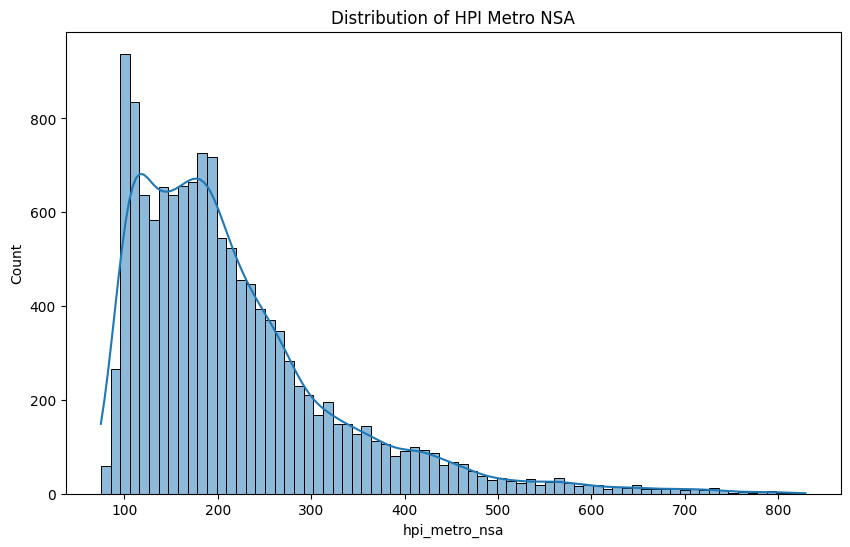

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(df['hpi_metro_nsa'], kde=True)
plt.title('Distribution of HPI Metro NSA')
plt.savefig('../reports/figures/target_distribution.png')
plt.show()

## 2. Correlation Matrix

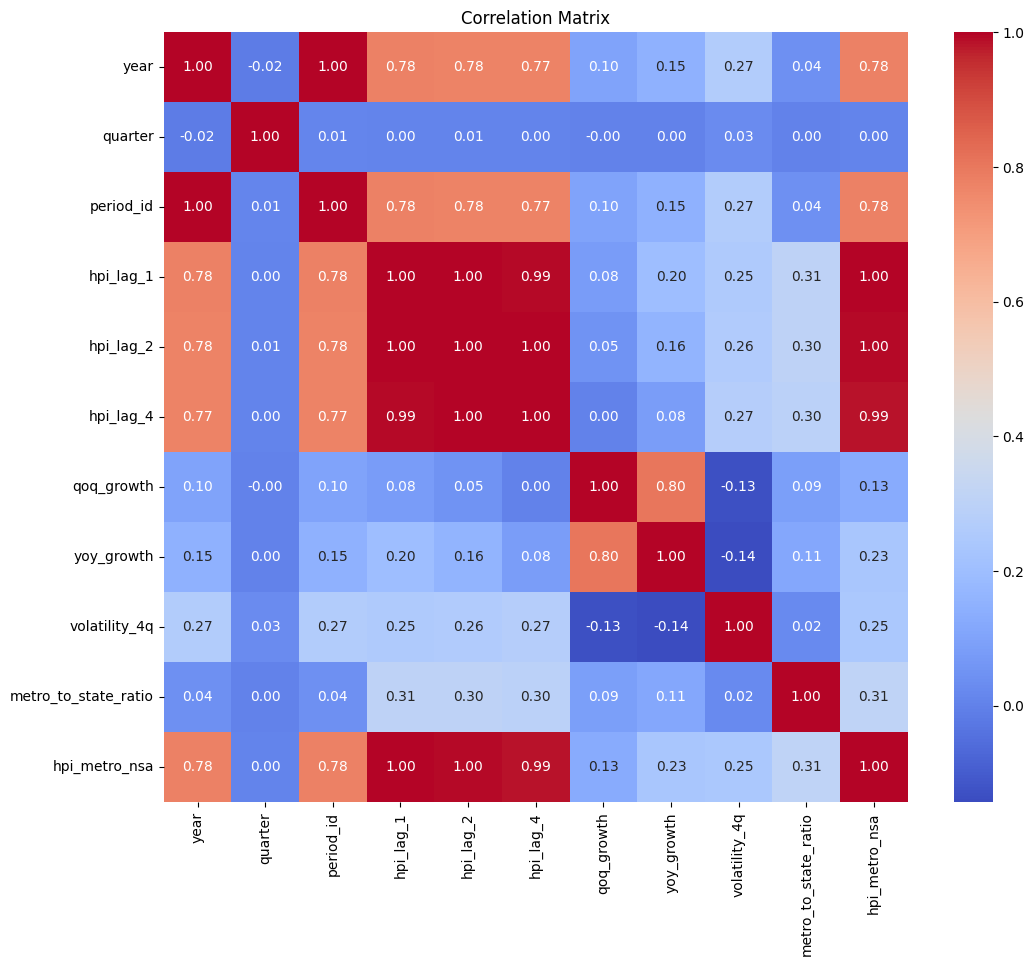

In [11]:
plt.figure(figsize=(12, 10))
# Select numeric columns only
numerics = df.select_dtypes(include=[np.number])
corr = numerics.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.savefig('../reports/figures/correlation_matrix.png')
plt.show()

## 3. High Correlation Features (Lag 1 vs Target)

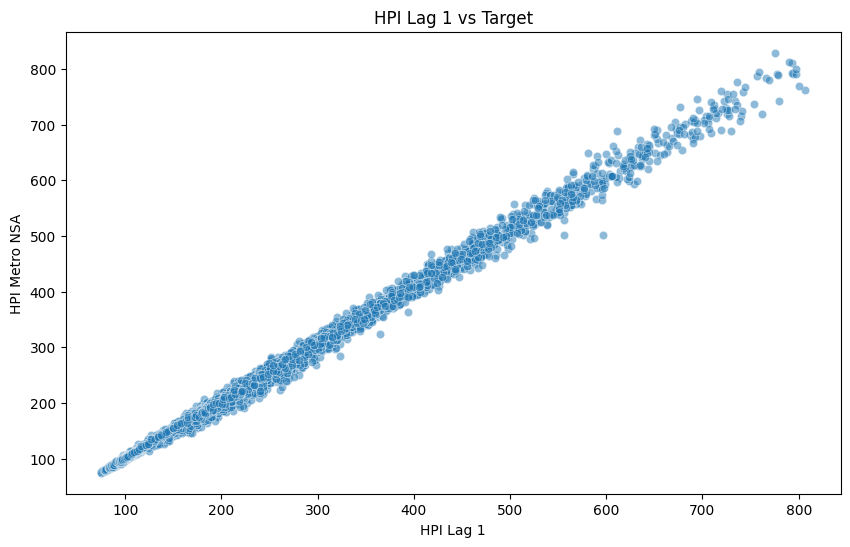

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='hpi_lag_1', y='hpi_metro_nsa', data=df, alpha=0.5)
plt.title('HPI Lag 1 vs Target')
plt.xlabel('HPI Lag 1')
plt.ylabel('HPI Metro NSA')
plt.savefig('../reports/figures/lag1_vs_target.png')
plt.show()

## 4. Outlier Check

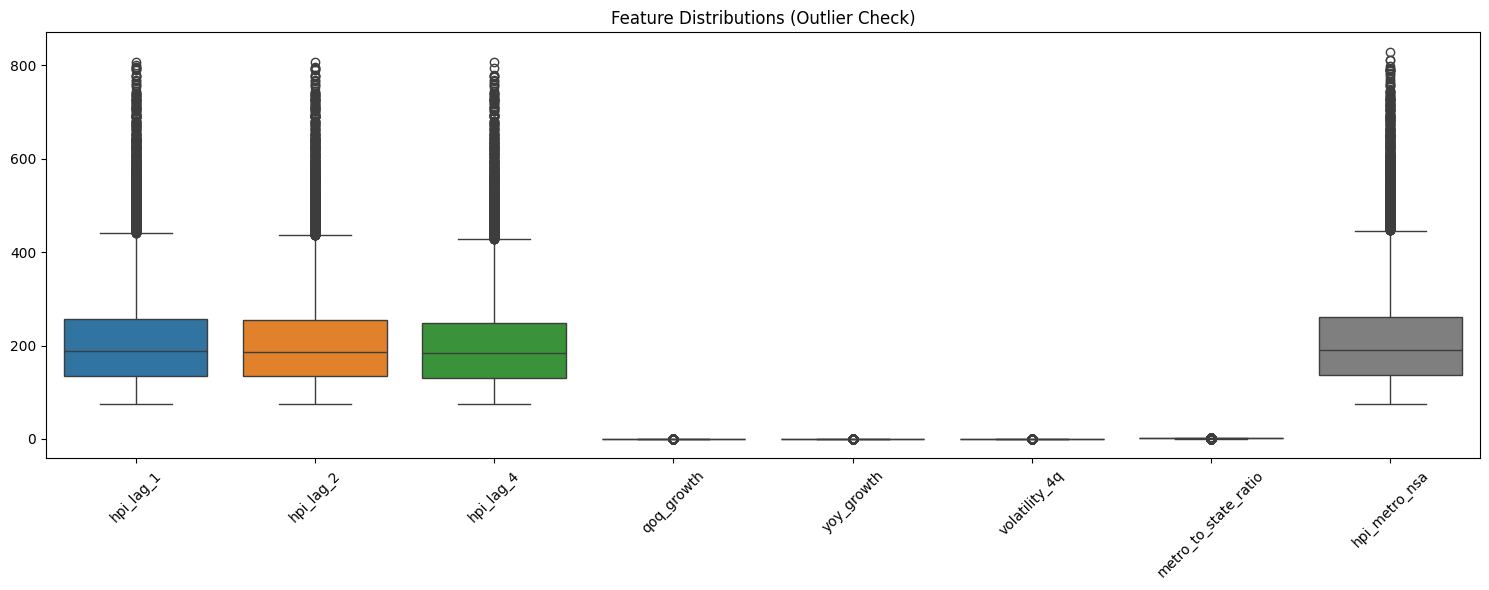

In [13]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=numerics.drop(columns=['year', 'quarter', 'period_id']))
plt.xticks(rotation=45)
plt.title('Feature Distributions (Outlier Check)')
plt.tight_layout()
plt.savefig('../reports/figures/outliers.png')
plt.show()

## 5. VIF Calculation

In [14]:
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    from statsmodels.tools.tools import add_constant
    
    print("\nCalculating VIF...")
    X = numerics.dropna()
    X = add_constant(X)
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    display(vif_data)
except ImportError:
    print("statsmodels not installed, skipping VIF")


Calculating VIF...


/Users/nguyenquy1411/Documents/dev/fpt/ady-2026/.venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
0,const,1.245408e+05
1,year,inf
2,quarter,inf
3,period_id,inf
4,hpi_lag_1,2.371505e+03
5,hpi_lag_2,9.613096e+02
6,hpi_lag_4,4.731333e+02
7,qoq_growth,7.762516e+00
8,yoy_growth,1.336606e+01
9,volatility_4q,1.139868e+00
